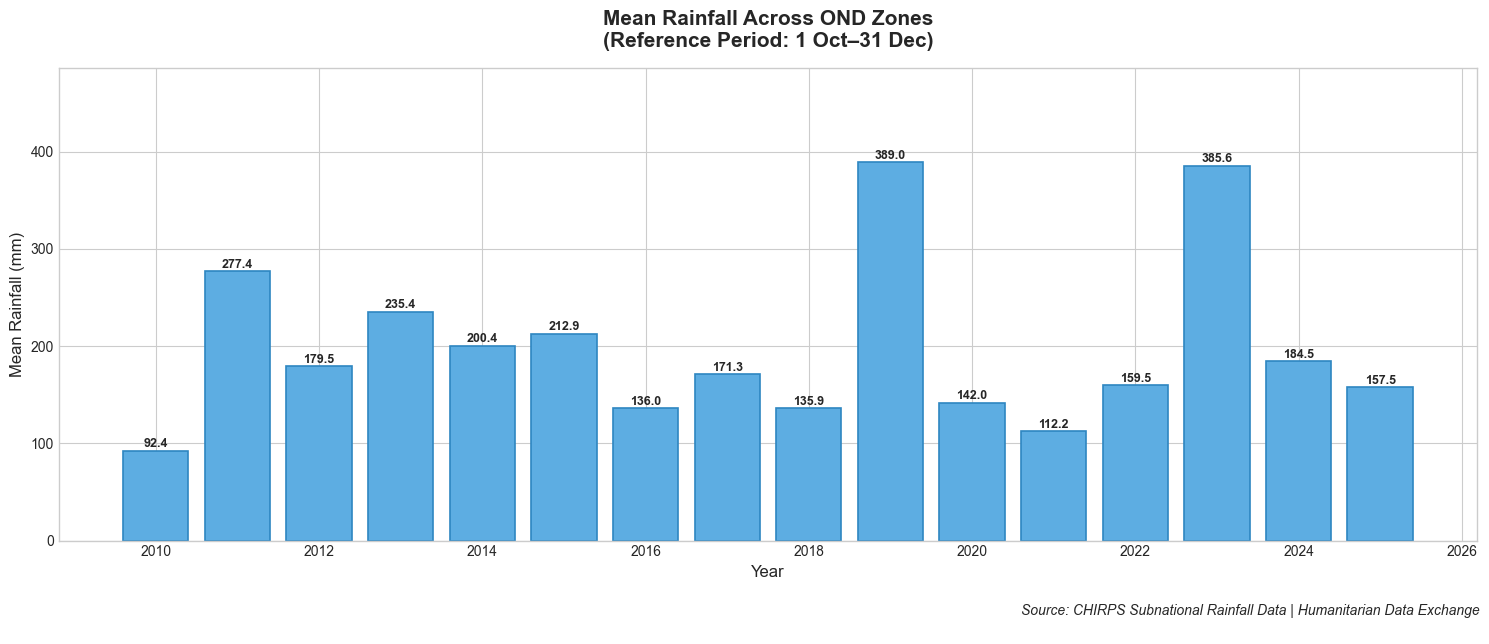

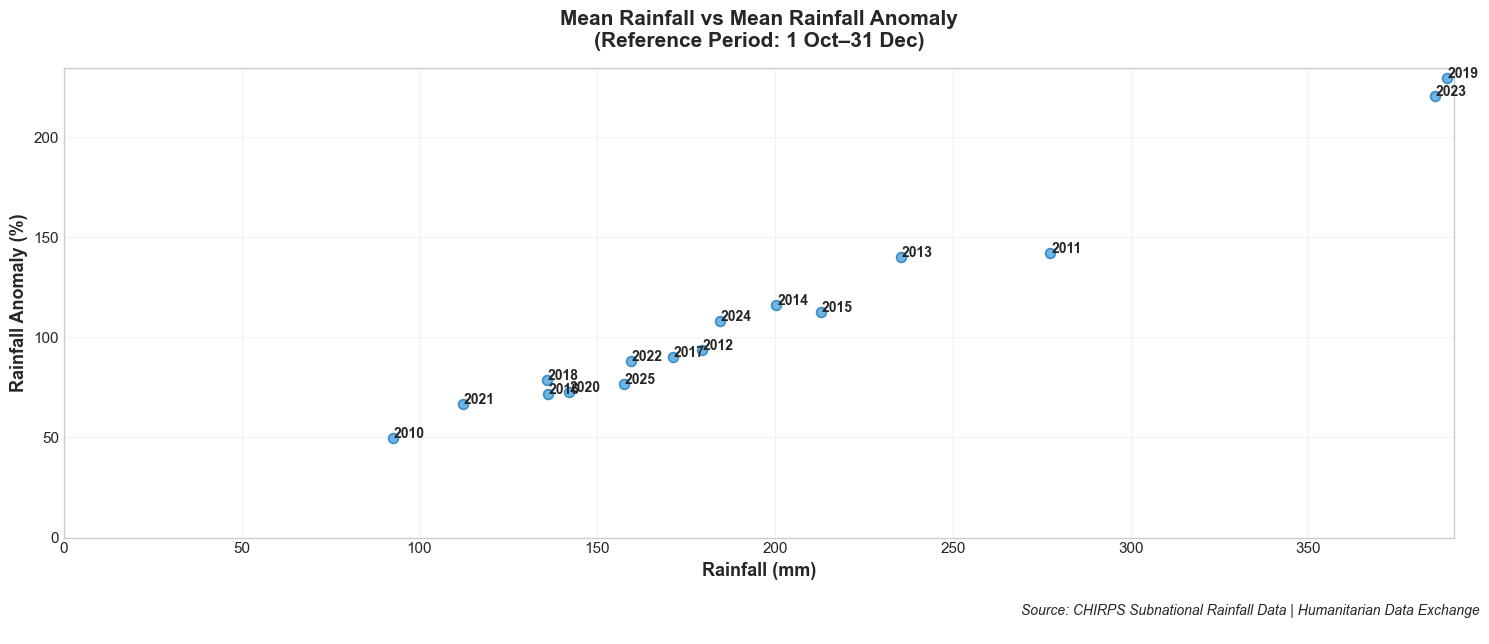

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

csv_path = "eth-rainfall-subnat-full-updated.csv"

zones = [
    "ET0508","ET0712","ET0721","ET0412","ET0722","ET0511","ET0723","ET0507","ET0504",
    "ET0502","ET0710","ET0503","ET0713","ET0505","ET0509","ET0510","ET0506","ET0707","ET0415"
]

# Load & filter
df = pd.read_csv(csv_path)
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df_filt = df[(df["PCODE"].isin(zones)) & (df["date"].dt.month == 12) & (df["date"].dt.day == 21) & (df["date"].dt.year >= 2010)].copy()
df_filt["year"] = df_filt["date"].dt.year
df_year_mean = df_filt.groupby("year")[["r3h","r3q"]].mean().reset_index()

# ---------------------------------- BAR PLOT ----------------------------------
plt.style.use("seaborn-v0_8-whitegrid")  # soft look

fig, ax = plt.subplots(figsize=(15,6))
bars = ax.bar(df_year_mean["year"], df_year_mean["r3h"], 
              color="#5DADE2", edgecolor="#2E86C1", linewidth=1.2)

# Label values neatly
for rect in bars:
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, height + 0.3, f"{height:.1f}",
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title(
    "Mean Rainfall Across OND Zones\n(Reference Period: 1 Oct–31 Dec)",
    fontsize=15, fontweight='bold', pad=15
)
# add caption
ax.set_ylabel("Mean Rainfall (mm)", fontsize=12)
ax.set_xlabel("Year", fontsize=12)
ax.tick_params(labelsize=10)
ax.set_ylim(0, df_year_mean["r3h"].max() * 1.25)
fig.text(
    0.99, -0.06,
    "Source: CHIRPS Subnational Rainfall Data | Humanitarian Data Exchange\n",
    ha="right",
    fontsize=10,
    style="italic",
    url="https://data.humdata.org/dataset/eth-rainfall-subnational"
)
plt.tight_layout()
plt.show()

# -------------------------------- SCATTER PLOT — Rainfall vs Anomaly --------------------------------
fig, ax = plt.subplots(figsize=(15,6))

ax.scatter(
    df_year_mean["r3h"], df_year_mean["r3q"],
    s=50, color="#5DADE2", alpha=0.9,
    edgecolor="#2E86C1", linewidth=1.2
)

# Annotate each year (integer only, no decimals)
for _, row in df_year_mean.iterrows():
    ax.text(
        row["r3h"] + 0.25, row["r3q"] + 0.02,
        str(int(row["year"])),                 
        fontsize=10, fontweight='bold'
    )

# -------- Plot styling --------
ax.set_title(
    "Mean Rainfall vs Mean Rainfall Anomaly\n(Reference Period: 1 Oct–31 Dec)",
    fontsize=15, fontweight='bold', pad=15
)

ax.set_xlabel("Rainfall (mm)", fontsize=13, fontweight='bold')
ax.set_ylabel("Rainfall Anomaly (%)", fontsize=13, fontweight='bold')
ax.grid(alpha=0.25)
ax.tick_params(labelsize=11)

# Give space above points
ax.set_ylim(0, df_year_mean["r3q"].max() + 5)
ax.set_xlim(0, df_year_mean["r3h"].max() + 2)
fig.text(
    0.99, -0.06,
    "Source: CHIRPS Subnational Rainfall Data | Humanitarian Data Exchange\n",
    ha="right",
    fontsize=10,
    style="italic",
    url="https://data.humdata.org/dataset/eth-rainfall-subnational"
)
plt.tight_layout()
plt.show()